# SVM: Bank Customer Churn
This notebook trains and evaluates a Support Vector Machine (SVM) model for customer churn prediction.

In [1]:
# 1. Load Processed Dataset
import pandas as pd
df = pd.read_csv('../data/processed/churn_processed.csv')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Shape: (10000, 14)
Columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
# 2. Define Features and Target
X = df.drop('Exited', axis=1)
y = df['Exited']
print('Features shape:', X.shape)
print('Target shape:', y.shape)

Features shape: (10000, 13)
Target shape: (10000,)


In [3]:
# 2b. Encode Categorical Features (One-Hot Encoding)
from sklearn.preprocessing import OneHotEncoder
df_cat = X.select_dtypes(include=['object'])
categorical_cols = df_cat.columns.tolist()
if categorical_cols:
    encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
    X_encoded = encoder.fit_transform(X[categorical_cols])
    encoded_cols = encoder.get_feature_names_out(categorical_cols)
    X_encoded_df = pd.DataFrame(X_encoded, columns=encoded_cols, index=X.index)
    X = pd.concat([X.drop(columns=categorical_cols), X_encoded_df], axis=1)
    print('Categorical columns encoded:', categorical_cols)
else:
    print('No categorical columns to encode.')
print('Features after encoding:', X.shape)

C:\Users\ACER\AppData\Local\Temp\ipykernel_2940\3755377155.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_cat = X.select_dtypes(include=['object'])


Categorical columns encoded: ['Surname', 'Geography', 'Gender']
Features after encoding: (10000, 2944)


In [4]:
# 3. Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Train shape:', X_train.shape, y_train.shape)
print('Test shape:', X_test.shape, y_test.shape)

Train shape: (8000, 2944) (8000,)
Test shape: (2000, 2944) (2000,)


In [5]:
# 4. Model Training (Fast Linear SVM)
from sklearn.svm import LinearSVC
svm = LinearSVC(class_weight='balanced', random_state=42, max_iter=5000)
svm.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseud

In [6]:
# 5. Prediction
y_pred = svm.predict(X_test)

Accuracy: 0.7110
Precision: 0.3817
Recall: 0.6781
F1-score: 0.4885


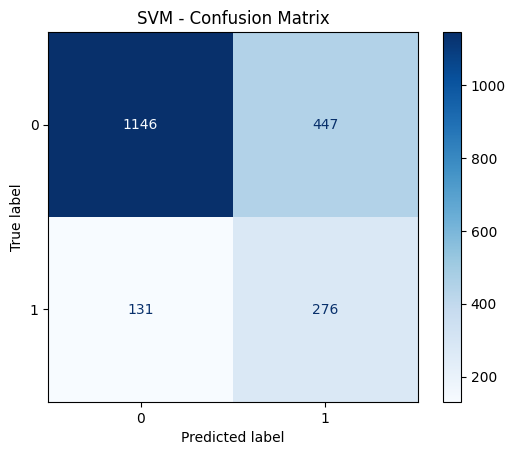

['../outputs/models/svm.joblib']

In [7]:
# 6. Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import json
from pathlib import Path
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-score: {f1:.4f}')
fig, ax = plt.subplots()
ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax, cmap='Blues')
plt.title('SVM - Confusion Matrix')
fig.savefig('../outputs/figures/svm_confusion_matrix.png')
plt.show()
metrics = {
    'model': 'SVM',
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1': f1
}
Path('../outputs/metrics').mkdir(parents=True, exist_ok=True)
with open('../outputs/metrics/svm_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
import joblib
Path('../outputs/models').mkdir(parents=True, exist_ok=True)
joblib.dump(svm, '../outputs/models/svm.joblib')

# 7. Conclusion

- The SVM model was trained and evaluated on the processed churn dataset.
- All results (metrics, confusion matrix, model) are saved in the outputs folders.
- Key metrics: accuracy, precision, recall, F1-score.
- Use the comparison notebook to see how this model performs against others.